# Sistema De Recomendación Híbrido Basado en Técnicas Colaborativas, Evolutivas y de Contenido

Extensión del algoritmo **HP-MOEA** (Hybrid Probabilistic Multi-Objective Evolutionary Algorithm)
que incorpora una métrica de novedad ponderada por afinidad temática para mejorar el tratamiento
de ítems *newcomers* (problema de inicio frío) en sistemas de recomendación.

Para más detalles sobre el enfoque original, ver el [paper de Wei et al. en IEEE Xplore](https://ieeexplore.ieee.org/abstract/document/9363322).

La documentación completa está disponible en el [libro del TFG](../docs/TFG%20-%20Junior%20Gutiérrez%20-%202025.pdf "TFG Junior Gutiérrez 2025").

## Requerimientos

Este proyecto requiere Python 3.10+ y las siguientes bibliotecas: NumPy, Pandas, Pymoo, Sortedcontainers y Matplotlib.

Instalar dependencias:

In [1]:
%pip install numpy pandas pymoo matplotlib sortedcontainers nbformat nbconvert 

Note: you may need to restart the kernel to use updated packages.


## Preprocesamiento de datos

Se utiliza el dataset [MovieLens 100K](https://grouplens.org/datasets/movielens/) (GroupLens, Universidad de Minnesota),
que contiene 100,000 calificaciones de usuarios a películas en el período 1996–2018, disponible libremente para investigación.

La implementación del preprocesamiento se encuentra en `preprocess.py`.

In [ ]:
import json

with open('../config.json') as f:
    config = json.load(f)

dataset_latest_small_path = config['paths']['dataset_latest_small_path']
dataset_100k_path = config['paths']['dataset_100k_path']
dataset_20m_path = config['paths']['dataset_20m_path']
data_path = config['paths']['data_path']
top_usuarios = config['preprocess']['top_usuarios']
newcomer_filter = config['preprocess']['newcomer_filter']

In [3]:
import preprocess

preprocess.main(dataset_100k_path, data_path, top_usuarios, newcomer_filter)


Leyendo el dataset desde: ../datasets/ml-100k/ratings.csv

Tamaño del dataframe original: 100000
Eliminando la columna 'timestamp'
Ordenando el dataset por la primera columna...
Seleccionando los 10000 usuarios películas más comunes...
Filtrando el dataframe para que solo contenga los usuarios seleccionados...
Películas que aparecen más de 5 veces: 1298
Películas que aparecen menos o igual a 5 veces (Newcomers): 384

Cantidad total de usuarios: 943
Cantidad total de peliculas: 1682
Tamaño del dataframe actual: 100000

Generando users2movie_ratings...
[2026-06-14 19:45:02] [INFO] [update_users2movie_ratings] [0.06 segundos] 5.0%
[2026-06-14 19:45:03] [INFO] [update_users2movie_ratings] [0.19 segundos] 15.0%
[2026-06-14 19:45:03] [INFO] [update_users2movie_ratings] [0.34 segundos] 25.0%
[2026-06-14 19:45:03] [INFO] [update_users2movie_ratings] [0.51 segundos] 35.0%
[2026-06-14 19:45:03] [INFO] [update_users2movie_ratings] [0.70 segundos] 45.0%
[2026-06-14 19:45:03] [INFO] [update_users2

## Filtrado colaborativo basado en usuarios

Luego del preprocesamiento, se calcula la puntuación esperada de ítems no calificados mediante
filtrado colaborativo basado en usuarios (User-Based CF) — la técnica base del pipeline HP-MOEA.

La implementación se encuentra en `User_based_CF.py`.

In [ ]:
import User_based_CF

K = config['user_based_cf']['K']
limit = config['user_based_cf']['limit']
eliminar_newcomers = config['user_based_cf']['eliminar_newcomers']
calcular_pesos = config['user_based_cf']['calcular_pesos'] # Debe estar True la primera vez que se ejecuta
hacer_test = config['user_based_cf']['hacer_test']

usermovie2predict_rating = User_based_CF.main(data_path, K, limit, eliminar_newcomers, calcular_pesos, hacer_test)

## Definición de parámetros del algoritmo

Se definen como constantes globales los parámetros clave del algoritmo.

In [ ]:
import random
import numpy as np

hp = config['hp_moea']

# Modo de ejecución
MODE = hp['mode']  # "original" | "modified"
test_mode = hp['test_mode']
logging = hp['logging']

# Rutas
results_dir = f'./results/{MODE}'

# Configuración HP-MOEA (valores del paper)
u_turning_point           = hp['u_turning_point']
L_tamano_lista            = hp['L_tamano_lista']
N_tamano_poblacion        = hp['N_tamano_poblacion']
T_iteraciones             = hp['T_iteraciones']
Pm_probabilidad_mutacion  = 1 / L_tamano_lista
r_max_calificacion_maxima = hp['r_max_calificacion_maxima']
max_profit                = 1
max_novelty               = 1
n_obj                     = hp['n_obj']

# Filtrado colaborativo
use_precalculated_CF = hp['use_precalculated_CF']
CF_config = hp['cf_config']

# Algoritmo multiobjetivo
algorithms = ["NSGA-II", "SMS-EMOA", "NSGA-III", "MOEA/D"]
algorithm_name = hp['algorithm_name']

# Modo test
if test_mode:
    T_iteraciones           = hp['test_mode_overrides']['T_iteraciones']
    N_tamano_poblacion      = hp['test_mode_overrides']['N_tamano_poblacion']
    Pm_probabilidad_mutacion = 1 / L_tamano_lista

# Reproducibilidad
nice_seed = config['seed'] if config.get('seed') is not None else random.randint(0, 100_000)
print(f"Semilla aleatoria generada: {nice_seed}")

# Estado global
poblacion_global  = []
historial_fitness = []
iteracion         = 0

## Ejecución del algoritmo HP-MOEA

Se ejecuta el algoritmo con los datos preprocesados y los parámetros previamente definidos

In [6]:
import contextlib
import io
import nbformat

def run_notebook(path: str, logging: bool = False):
    with open(path, encoding="utf-8") as f:
        nb = nbformat.read(f, as_version=4)

    ctx = contextlib.nullcontext() if logging else contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO())
    
    with contextlib.ExitStack() as stack:
        if not logging:
            stack.enter_context(contextlib.redirect_stdout(io.StringIO()))
            stack.enter_context(contextlib.redirect_stderr(io.StringIO()))
        
        for celda in nb.cells:
            if celda.cell_type == "code":
                exec(celda.source, globals())

run_notebook("HP-MOEA.ipynb", logging=True)

[2026-06-14 19:45:15] [INFO] [LOAD_DATASET] [0.00 segundos] Cargamos los datos preprocesados

Longitud de los datos preprocesados:
users2movie_ratings:  1097886
users2predict_movie_ratings:  34436686
movies_info:  255146

U_cant_usuarios: 943
Cantidad de peliculas: 1682
ID_MIN (movies): 1
ID_MAX (movies): 1682
Cantidad de newcomers: 384
[2026-06-14 19:45:16] [SUCCESS] [LOAD_DATASET] [1.04 segundos] Datos preprocesados cargados correctamente
[2026-06-14 19:45:18] [INFO] [HP_MOEA_CLASS] [0.00 segundos] Se inicializo una instancia de la clase HP_MOEA_CLASS, la configuración es:
[2026-06-14 19:45:18] [INFO] [HP_MOEA_CLASS] [0.00 segundos] test_mode = True
[2026-06-14 19:45:18] [INFO] [HP_MOEA_CLASS] [0.00 segundos] u_turning_point = 500
[2026-06-14 19:45:18] [INFO] [HP_MOEA_CLASS] [0.00 segundos] L_tamano_lista = 10
[2026-06-14 19:45:18] [INFO] [HP_MOEA_CLASS] [0.00 segundos] N_tamano_poblacion = 50
[2026-06-14 19:45:18] [INFO] [HP_MOEA_CLASS] [0.00 segundos] T_iteraciones = 50
[2026-06-14

## Análisis de resultados y visualización
Esta sección presenta los resultados obtenidos y su visualización para facilitar la interpretación del desempeño del algoritmo.

In [7]:
import pickle as pkl
from datetime import datetime
import os

def guardar_archivo():
    global poblacion_final
    fecha_hora = datetime.now().strftime('%Y%m%d_%H%M%S')
    archivo_guardar = {
        "fitnessF": poblacion_final.fitnessF,
        "poblacionX": poblacion_final.poblacionX
    }

    if not os.path.exists(results_dir):
        os.makedirs(results_dir)

    filename = f'{results_dir}/poblacion_final_{algorithm_name}_{N_tamano_poblacion}_{T_iteraciones}_{fecha_hora}.pkl'
    with open(filename, 'wb') as f:
        pkl.dump(archivo_guardar, f)

    print(f'Resultados guardados en: {filename}')

guardar_archivo()

Resultados guardados en: ./results/original/poblacion_final_NSGA-II_50_50_20260614_195145.pkl


FINAL:
El hipervolumen de la población final es 0.5674730297438503
La población final es de 50 individuos


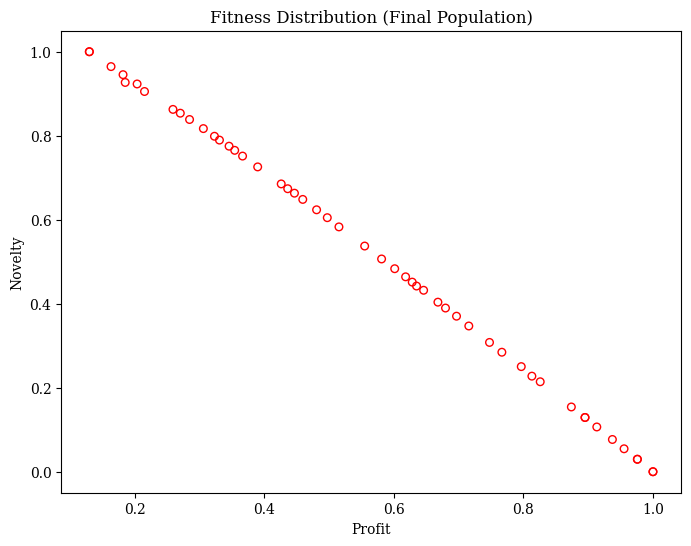

In [8]:
from pymoo.indicators.hv import Hypervolume
from pymoo.visualization.scatter import Scatter

import matplotlib.pyplot as plt

import logger

log = logger.logger_class('RESULTADOS')
ref_point = np.zeros(n_obj)
hv = Hypervolume(ref_point=ref_point)

### POBLACIÓN FINAL
print(f'FINAL:')
global poblacion_final
fitnessF = poblacion_final.get_fitness_F()
hv_value = hv.do(fitnessF)

print(f'El hipervolumen de la población final es {hv_value}')
print(f'La población final es de {len(poblacion_final.get_poblacion_X())} individuos')
plot_final = Scatter(
    title="Fitness Distribution (Final Population)",
    labels=["Profit", "Novelty"]
)
plot_final.add(fitnessF * -1, s=30, facecolors='none', edgecolors='r', label="Final Population")
plot_final.show()